In [1]:
import pandas as pd

# Load data
file_path = r"D:\Tissa\visualisasi_data\flights_sample_10000.csv"
df = pd.read_csv(file_path)

# Cek beberapa baris awal
print(df.head())


      FL_DATE                AIRLINE                AIRLINE_DOT AIRLINE_CODE  \
0  2019-01-09  United Air Lines Inc.  United Air Lines Inc.: UA           UA   
1  2022-11-19   Delta Air Lines Inc.   Delta Air Lines Inc.: DL           DL   
2  2022-07-22  United Air Lines Inc.  United Air Lines Inc.: UA           UA   
3  2023-03-06   Delta Air Lines Inc.   Delta Air Lines Inc.: DL           DL   
4  2020-02-23       Spirit Air Lines       Spirit Air Lines: NK           NK   

   DOT_CODE  FL_NUMBER ORIGIN          ORIGIN_CITY DEST  \
0     19977       1562    FLL  Fort Lauderdale, FL  EWR   
1     19790       1149    MSP      Minneapolis, MN  SEA   
2     19977        459    DEN           Denver, CO  MSP   
3     19790       2295    MSP      Minneapolis, MN  SFO   
4     20416        407    MCO          Orlando, FL  DFW   

               DEST_CITY  ...  DIVERTED  CRS_ELAPSED_TIME  ELAPSED_TIME  \
0             Newark, NJ  ...       0.0             186.0         176.0   
1            S

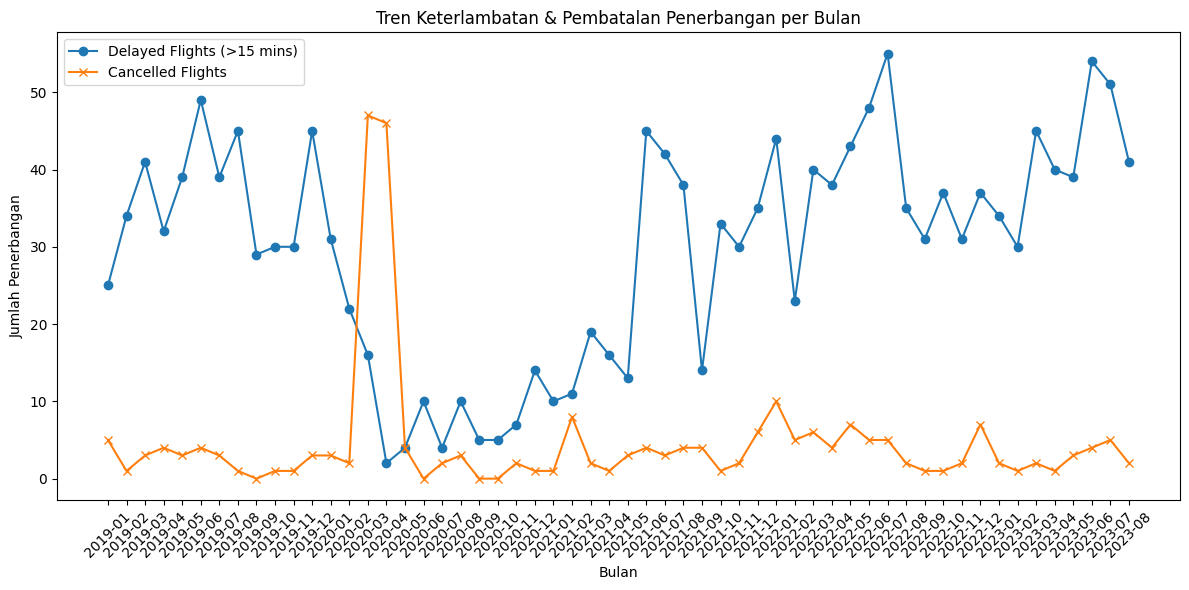

In [2]:
import matplotlib.pyplot as plt

# Ubah kolom FL_DATE ke datetime
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# Buat kolom bulan
df['Month'] = df['FL_DATE'].dt.to_period('M').astype(str)

# Agregasi jumlah pembatalan dan keterlambatan
monthly_stats = df.groupby('Month').agg({
    'CANCELLED': 'sum',
    'DEP_DELAY': lambda x: (x > 15).sum()  # Hitung yang delay lebih dari 15 menit
}).reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_stats['Month'], monthly_stats['DEP_DELAY'], marker='o', label='Delayed Flights (>15 mins)')
plt.plot(monthly_stats['Month'], monthly_stats['CANCELLED'], marker='x', label='Cancelled Flights')
plt.xticks(rotation=45)
plt.title('Tren Keterlambatan & Pembatalan Penerbangan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penerbangan')
plt.legend()
plt.tight_layout()
plt.show()


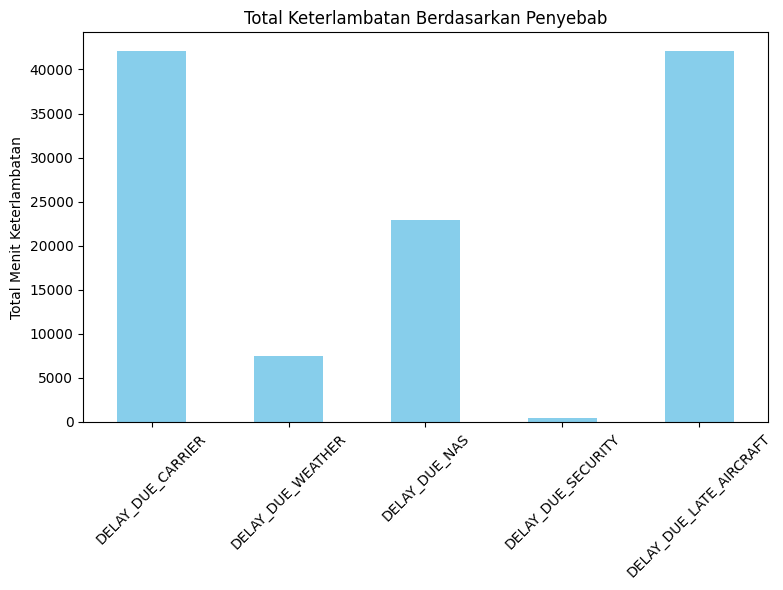

In [3]:
# Ambil hanya kolom penyebab delay
delay_cols = [
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]

# Hitung total per penyebab
total_delays = df[delay_cols].sum()

# Plot
plt.figure(figsize=(8, 6))
total_delays.plot(kind='bar', color='skyblue')
plt.title('Total Keterlambatan Berdasarkan Penyebab')
plt.ylabel('Total Menit Keterlambatan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Tiara\AppData\Local\Temp\ipykernel_14260\2601560248.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_avg_delay.values, y=airline_avg_delay.index, palette='viridis')


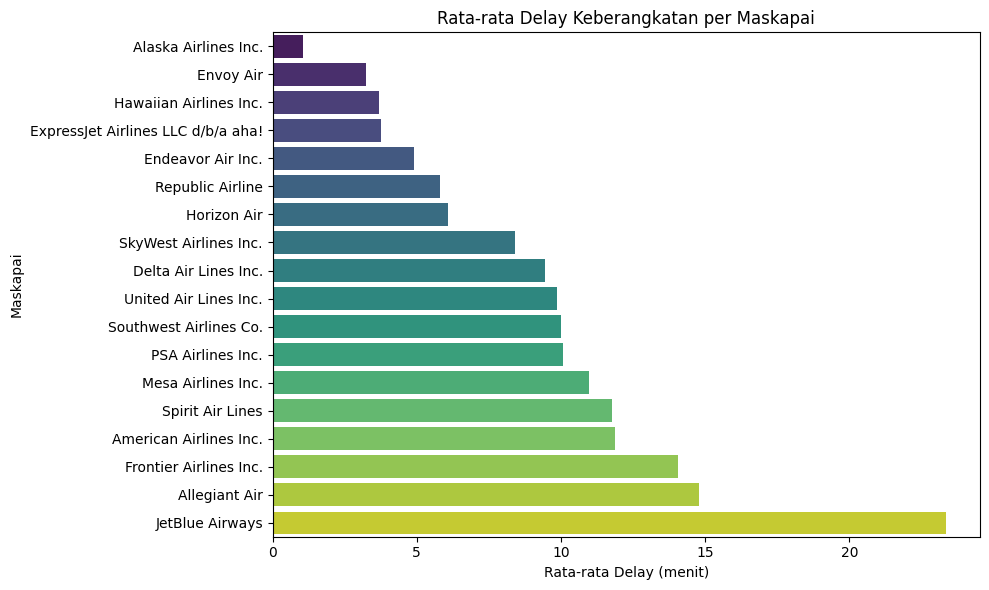

In [4]:
import seaborn as sns

# Filter delay valid (tidak null) dan group by maskapai
airline_delay = df[['AIRLINE', 'DEP_DELAY']].dropna()
airline_avg_delay = airline_delay.groupby('AIRLINE')['DEP_DELAY'].mean().sort_values()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=airline_avg_delay.values, y=airline_avg_delay.index, palette='viridis')
plt.title('Rata-rata Delay Keberangkatan per Maskapai')
plt.xlabel('Rata-rata Delay (menit)')
plt.ylabel('Maskapai')
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load data
file_path = r"D:\Tissa\visualisasi_data\flights_sample_10000.csv"
df = pd.read_csv(file_path)

# Proses kolom waktu
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek
df['MONTH'] = df['FL_DATE'].dt.month

# Target kolom: delay > 15 menit atau tidak
df['DELAYED'] = df['DEP_DELAY'] > 15

# Pisahkan fitur dan label
X = df[['AIRLINE', 'ORIGIN', 'DEST', 'DAY_OF_WEEK', 'MONTH']]
y = df['DELAYED']

# Pipeline preprocessing
categorical_cols = ['AIRLINE', 'ORIGIN', 'DEST']
numerical_cols = ['DAY_OF_WEEK', 'MONTH']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', SimpleImputer(strategy='mean'), numerical_cols)
])

# Gabung preprocessing + model
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
clf.fit(X_train, y_train)

# Evaluasi
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.84      0.97      0.90      2506
        True       0.16      0.03      0.05       494

    accuracy                           0.82      3000
   macro avg       0.50      0.50      0.47      3000
weighted avg       0.72      0.82      0.76      3000



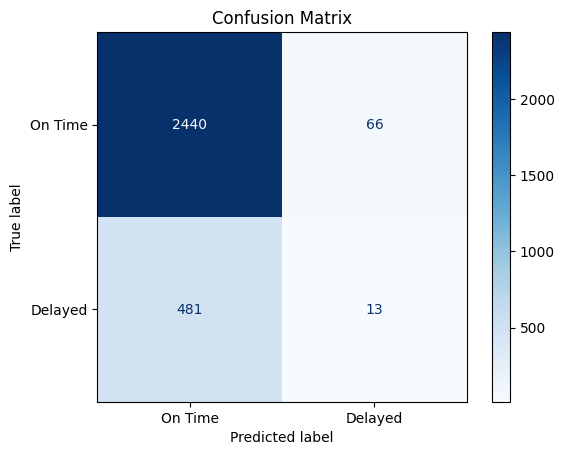

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Visualisasi 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

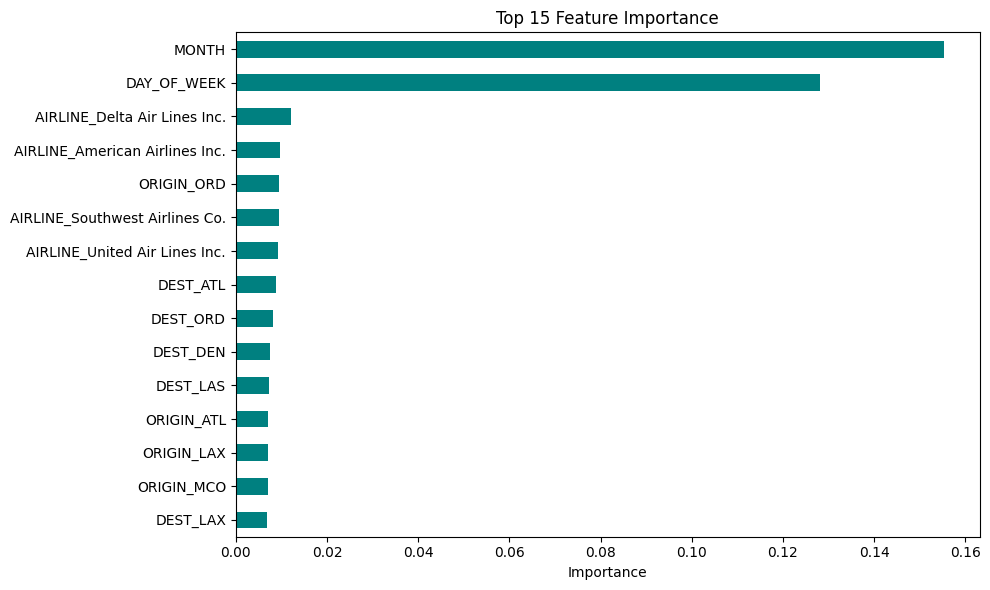

In [7]:
import numpy as np  # pastikan numpy sudah di-import

# Ambil feature names setelah one-hot encoding
ohe = clf.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_cols)

# Gabungkan semua nama fitur (categorical + numerical)
all_features = np.concatenate([ohe_features, numerical_cols])

# Ambil nilai feature importance dari Random Forest
importances = clf.named_steps['classifier'].feature_importances_

# Visualisasi 15 fitur terpenting
feat_importance = pd.Series(importances, index=all_features).sort_values(ascending=False)[:15]
plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


C:\Users\Tiara\AppData\Local\Temp\ipykernel_14260\1114439899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, palette='Set2')


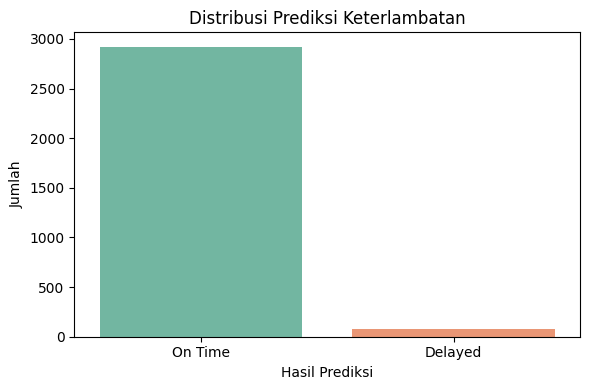

In [8]:
# Visualisasi 3: Distribusi Hasil Prediksi
plt.figure(figsize=(6, 4))
sns.countplot(x=y_pred, palette='Set2')
plt.title("Distribusi Prediksi Keterlambatan")
plt.xticks([0, 1], ['On Time', 'Delayed'])
plt.xlabel("Hasil Prediksi")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()